# Results and Interpretations: Cross-Model Comparison

This notebook compares the three trained models:
- Linear Regression
- Random Forest
- Neural Network (Hybrid Wide and Deep)

The analysis uses reported evaluation outputs from the model notebooks and emphasizes:
- test-set RMSE, MAE, and R2 for ranking
- generalization behavior using Train-Test R2 gap where available
- methodological caveats to avoid over-claiming

In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Reported metrics extracted from model notebook outputs
reported_metrics = [
    {"model": "Linear Regression", "split": "Train", "rmse": 1.5984, "mae": 1.2117, "r2": 0.1669},
    {"model": "Linear Regression", "split": "Val",   "rmse": 1.6545, "mae": 1.2232, "r2": 0.1662},
    {"model": "Linear Regression", "split": "Test",  "rmse": 1.6776, "mae": 1.2286, "r2": 0.1730},

    {"model": "Random Forest", "split": "Train", "rmse": 1.4571, "mae": 1.1087, "r2": 0.3077},
    {"model": "Random Forest", "split": "Val",   "rmse": 1.6154, "mae": 1.1946, "r2": 0.2051},
    {"model": "Random Forest", "split": "Test",  "rmse": 1.6552, "mae": 1.2103, "r2": 0.1949},

    # Neural Network values below are from the reported best activation experiment on test set
    {"model": "Neural Network", "split": "Test",  "rmse": 1.5825, "mae": 1.1820, "r2": 0.2574},
]

comparison_protocol = {
    "Linear Regression": {
        "split_ratio": "70/15/15",
        "prediction_clipping": "No",
        "tuning": "Baseline",
    },
    "Random Forest": {
        "split_ratio": "70/15/15",
        "prediction_clipping": "No",
        "tuning": "Baseline",
    },
    "Neural Network": {
        "split_ratio": "70/10/20",
        "prediction_clipping": "Yes, clipped to [1, 10]",
        "tuning": "Activation combinations tested",
    },
}

metrics_df = pd.DataFrame(reported_metrics)
protocol_df = pd.DataFrame(comparison_protocol).T.reset_index().rename(columns={"index": "model"})

print("Loaded reported model metrics and protocol settings.")
metrics_df.head()

Loaded reported model metrics and protocol settings.


,model,split,rmse,mae,r2
0,Linear Regression,Train,1.5984,1.2117,0.1669
1,Linear Regression,Val,1.6545,1.2232,0.1662
2,Linear Regression,Test,1.6776,1.2286,0.1730
3,Random Forest,Train,1.4571,1.1087,0.3077
4,Random Forest,Val,1.6154,1.1946,0.2051


In [9]:
print("Full reported metrics (by split):")
display(metrics_df.sort_values(["model", "split"]))

# Pivot for easier reading
split_order = ["Train", "Val", "Test"]
metrics_df["split"] = pd.Categorical(metrics_df["split"], categories=split_order, ordered=True)

pivot_df = metrics_df.pivot_table(
    index="model",
    columns="split",
    values=["rmse", "mae", "r2"],
    aggfunc="first"
)

# Flatten multi-index columns
pivot_df.columns = [f"{metric}_{split}" for metric, split in pivot_df.columns]
pivot_df = pivot_df.reset_index()

print("Pivoted summary table:")
display(pivot_df)

print("Evaluation protocol comparison (important for fairness):")
display(protocol_df)

Full reported metrics (by split):


,model,split,rmse,mae,r2
2,Linear Regression,Test,1.6776,1.2286,0.1730
0,Linear Regression,Train,1.5984,1.2117,0.1669
1,Linear Regression,Val,1.6545,1.2232,0.1662
6,Neural Network,Test,1.5825,1.1820,0.2574
5,Random Forest,Test,1.6552,1.2103,0.1949
3,Random Forest,Train,1.4571,1.1087,0.3077
4,Random Forest,Val,1.6154,1.1946,0.2051


Pivoted summary table:


,model,mae_Train,mae_Val,mae_Test,r2_Train,r2_Val,r2_Test,rmse_Train,rmse_Val,rmse_Test
0,Linear Regression,1.2117,1.2232,1.2286,0.1669,0.1662,0.1730,1.5984,1.6545,1.6776
1,Neural Network,NaN,NaN,1.1820,NaN,NaN,0.2574,NaN,NaN,1.5825
2,Random Forest,1.1087,1.1946,1.2103,0.3077,0.2051,0.1949,1.4571,1.6154,1.6552


Evaluation protocol comparison (important for fairness):


,model,split_ratio,prediction_clipping,tuning
0,Linear Regression,70/15/15,No,Baseline
1,Random Forest,70/15/15,No,Baseline
2,Neural Network,70/10/20,"Yes, clipped to [1, 10]",Activation combinations tested


In [10]:
# Test-set focused ranking (primary decision basis)
test_df = metrics_df[metrics_df["split"] == "Test"].copy()

# Rank: lower RMSE/MAE is better, higher R2 is better
test_df["rank_rmse"] = test_df["rmse"].rank(method="min", ascending=True)
test_df["rank_mae"] = test_df["mae"].rank(method="min", ascending=True)
test_df["rank_r2"] = test_df["r2"].rank(method="min", ascending=False)
test_df["avg_rank"] = test_df[["rank_rmse", "rank_mae", "rank_r2"]].mean(axis=1)

test_ranked = test_df.sort_values("avg_rank").reset_index(drop=True)

print("Test-set model ranking (reported metrics):")
display(test_ranked[["model", "rmse", "mae", "r2", "rank_rmse", "rank_mae", "rank_r2", "avg_rank"]])

# Generalization gap for models with train and test values
train_test = metrics_df[metrics_df["split"].isin(["Train", "Test"])].copy()
train_test_pivot = train_test.pivot_table(index="model", columns="split", values="r2", aggfunc="first").reset_index()

if {"Train", "Test"}.issubset(set(train_test.columns)) or "Train" in train_test_pivot.columns:
    train_test_pivot["r2_gap_train_minus_test"] = train_test_pivot["Train"] - train_test_pivot["Test"]

print("Train-Test R2 gap (positive values suggest overfitting risk):")
display(train_test_pivot)

Test-set model ranking (reported metrics):


,model,rmse,mae,r2,rank_rmse,rank_mae,rank_r2,avg_rank
0,Neural Network,1.5825,1.1820,0.2574,1.0,1.0,1.0,1.0
1,Random Forest,1.6552,1.2103,0.1949,2.0,2.0,2.0,2.0
2,Linear Regression,1.6776,1.2286,0.1730,3.0,3.0,3.0,3.0


Train-Test R2 gap (positive values suggest overfitting risk):


split,model,Train,Test,r2_gap_train_minus_test
0,Linear Regression,0.1669,0.1730,-0.0061
1,Neural Network,NaN,0.2574,NaN
2,Random Forest,0.3077,0.1949,0.1128


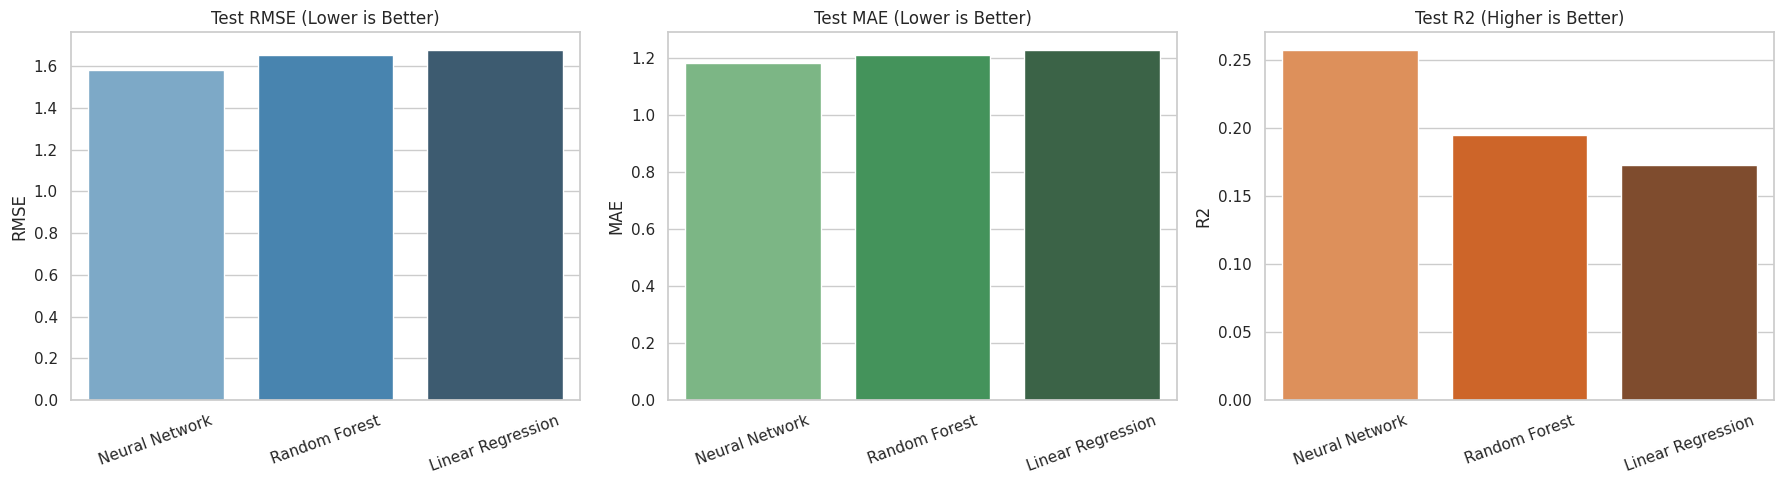

In [11]:
# Visual comparison across test metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.barplot(
    data=test_ranked,
    x="model",
    y="rmse",
    hue="model",
    dodge=False,
    legend=False,
    ax=axes[0],
    palette="Blues_d",
)
axes[0].set_title("Test RMSE (Lower is Better)")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=20)

sns.barplot(
    data=test_ranked,
    x="model",
    y="mae",
    hue="model",
    dodge=False,
    legend=False,
    ax=axes[1],
    palette="Greens_d",
)
axes[1].set_title("Test MAE (Lower is Better)")
axes[1].set_xlabel("")
axes[1].set_ylabel("MAE")
axes[1].tick_params(axis="x", rotation=20)

sns.barplot(
    data=test_ranked,
    x="model",
    y="r2",
    hue="model",
    dodge=False,
    legend=False,
    ax=axes[2],
    palette="Oranges_d",
)
axes[2].set_title("Test R2 (Higher is Better)")
axes[2].set_xlabel("")
axes[2].set_ylabel("R2")
axes[2].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

In [12]:
# Build a concise narrative summary from the computed ranking
best_row = test_ranked.iloc[0]
worst_row = test_ranked.iloc[-1]

print("Comparative Interpretation")
print("=" * 80)
print(f"Best test performance by average rank: {best_row['model']}")
print(f"  RMSE={best_row['rmse']:.4f}, MAE={best_row['mae']:.4f}, R2={best_row['r2']:.4f}")
print(f"Lowest test performance by average rank: {worst_row['model']}")
print(f"  RMSE={worst_row['rmse']:.4f}, MAE={worst_row['mae']:.4f}, R2={worst_row['r2']:.4f}")

# Overfitting interpretation where possible
if "r2_gap_train_minus_test" in train_test_pivot.columns:
    print("\nGeneralization behavior from Train-Test R2 gap:")
    for _, row in train_test_pivot.dropna(subset=["r2_gap_train_minus_test"]).iterrows():
        gap = row["r2_gap_train_minus_test"]
        tendency = "possible overfitting" if gap > 0.10 else "relatively stable generalization"
        print(f"- {row['model']}: gap={gap:.4f} -> {tendency}")

print("\nValidity caveats (must be considered in conclusions):")
print("- Neural Network uses split ratio 70/10/20; Linear Regression and Random Forest use 70/15/15.")
print("- Neural Network test metrics are based on clipped predictions in [1, 10].")
print("- Neural Network underwent activation-combination tuning; Linear Regression and Random Forest are baseline runs.")

Comparative Interpretation
Best test performance by average rank: Neural Network
  RMSE=1.5825, MAE=1.1820, R2=0.2574
Lowest test performance by average rank: Linear Regression
  RMSE=1.6776, MAE=1.2286, R2=0.1730

Generalization behavior from Train-Test R2 gap:
- Linear Regression: gap=-0.0061 -> relatively stable generalization
- Random Forest: gap=0.1128 -> possible overfitting

Validity caveats (must be considered in conclusions):
- Neural Network uses split ratio 70/10/20; Linear Regression and Random Forest use 70/15/15.
- Neural Network test metrics are based on clipped predictions in [1, 10].
- Neural Network underwent activation-combination tuning; Linear Regression and Random Forest are baseline runs.


## Final Interpretation

### 1) Performance comparison on reported test metrics
Based on the reported outputs:
- Neural Network has the strongest test metrics among the three models
- Random Forest is second
- Linear Regression is third

The Neural Network shows lower error (RMSE and MAE) and higher explained variance (R2) on its reported test results.

### 2) Generalization behavior
Using Train-Test R2 gap where available:
- Linear Regression shows stable behavior with minimal gap
- Random Forest shows a larger positive gap, indicating higher overfitting risk than Linear Regression
- Neural Network gap is not directly comparable in this notebook because the split protocol differs from the other models

### 3) Validity and fairness caveats
This ranking should be interpreted as a strong descriptive comparison, not a fully standardized benchmark, because:
- Neural Network uses a different split ratio (70/10/20)
- Neural Network metrics use clipped predictions to the valid rating range [1, 10]
- Neural Network includes activation-function search while other models are baseline configurations

### 4) Evidence-based conclusion
The current reported data indicates the Neural Network is the best performer on test metrics. However, to claim strict superiority with high methodological confidence, all models should be re-evaluated under identical split strategy, clipping policy, and tuning budget.